# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [24]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

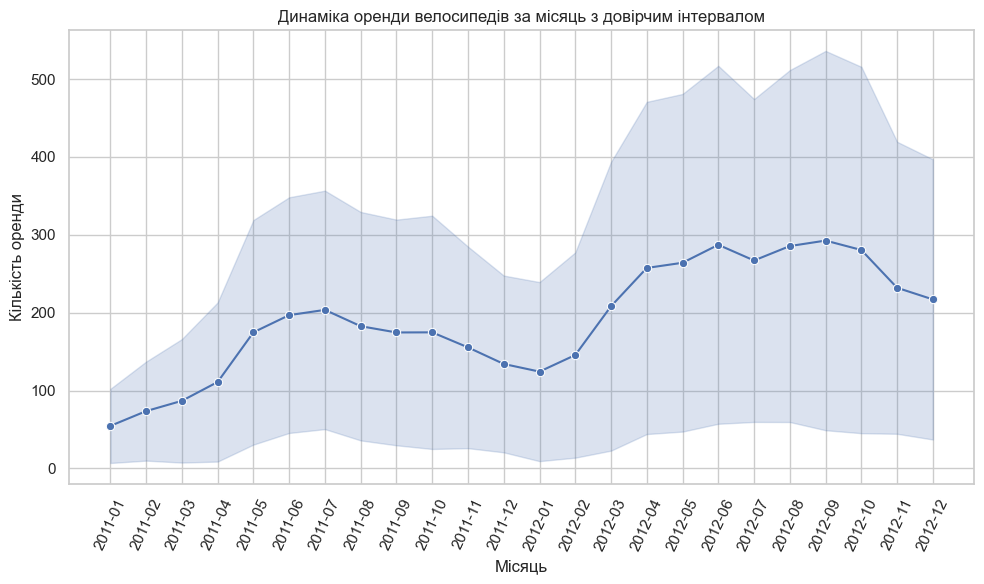

In [25]:
plt.figure(figsize=(10, 6))
sns.lineplot(df, x='month_year', y='count', marker='o', errorbar='sd')
plt.title('Динаміка оренди велосипедів за місяць з довірчим інтервалом')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=65)
plt.tight_layout();

In [ ]:
Найбільша невизначенність даних в червні- жовтні кожного року. На графіку це зображено більшою площею фігури.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

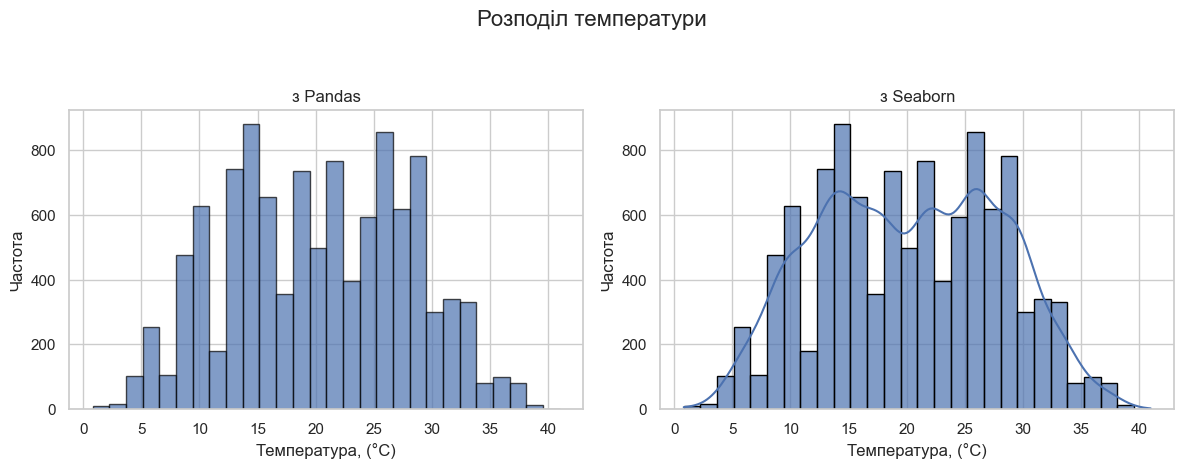

In [59]:
# Два графіки на одній фігурі

fig=plt.figure(figsize=(12, 8))

# Спосіб Pandas
plt.subplot(2, 2, 1)
df['temp'].plot.hist(
    bins=28,
    alpha=0.7,
    edgecolor='black',
    title='з Pandas',
    xlabel='Температура, (°C)',
    ylabel='Частота',
)
plt.tight_layout()

# Спосіб Seaborn
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='temp',bins=28, kde=True, alpha=0.7, edgecolor='black' )
plt.title('з Seaborn')
plt.xlabel('Температура, (°C)')
plt.ylabel('Частота')
plt.tight_layout()

# Загальний вигляд
fig.suptitle('Розподіл температури', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # залишаємо місце для заголовка
plt.show()


In [ ]:
Графіки ідентичні, різниця в наявності лінії щільності.
kde лінія показує щільність даних. Чим вища лінія в окремій точці, тим більше вірогідність цього значення в наборі даних. 

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

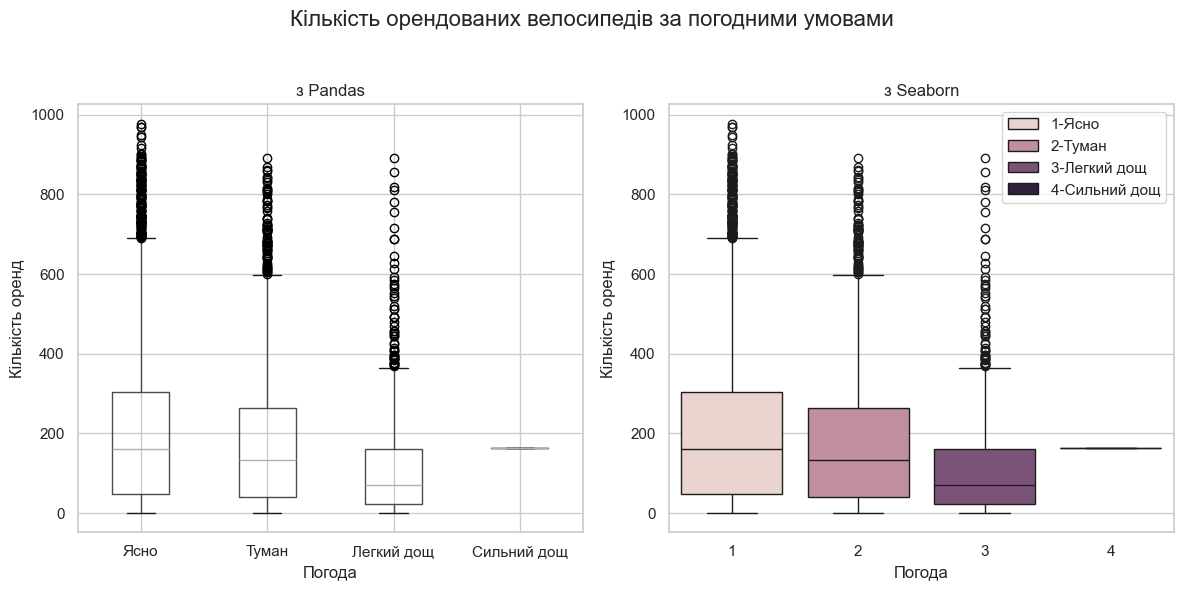

In [97]:
# Два графіки на одній фігурі

fig=plt.figure(figsize=(12, 6))

# Спосіб Pandas
f1=plt.subplot(1, 2, 1)
df.boxplot(
    column='count',
    by='weather',
    grid = True,
    ax=f1
  )
plt.title('з Pandas')
plt.suptitle('')  # Видаляємо автоматичний заголовок
plt.xlabel('Погода')
plt.ylabel('Кількість оренд')
plt.xticks([1, 2, 3, 4] , ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])


# Спосіб Seaborn
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='weather', y='count', hue='weather',legend = False)
plt.title('з Seaborn')
plt.xlabel('Погода')
plt.ylabel('Кількість оренд')
plt.legend(labels = ['1-Ясно', '2-Туман', '3-Легкий дощ', '4-Сильний дощ'])


plt.tight_layout()

fig.suptitle('Кількість орендованих велосипедів за погодними умовами', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # залишаємо місце для заголовка
plt.show()


In [ ]:
Графік Seaborn більш естетичний. 
Pandas виглядає просто та сухо.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


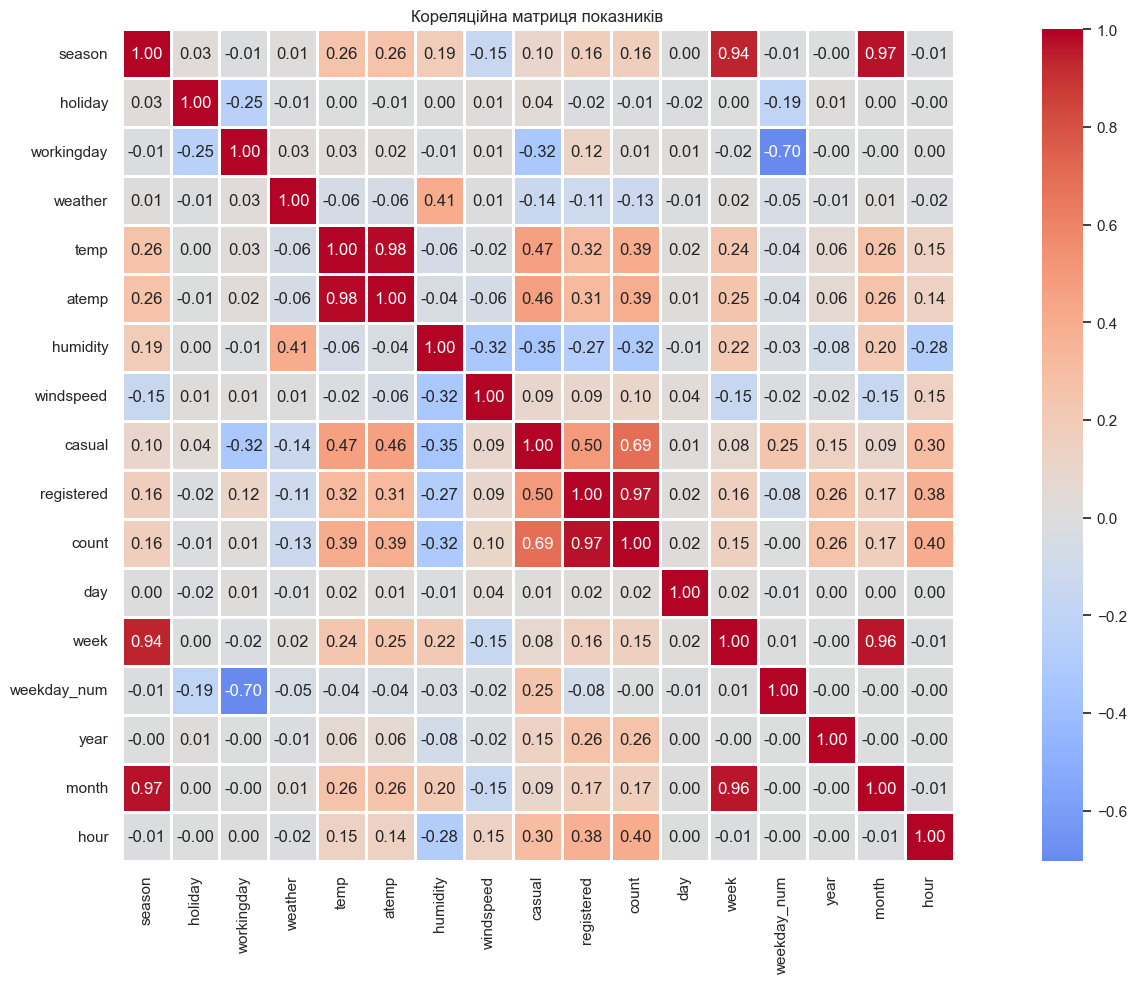

In [105]:
df_num = df.select_dtypes(include='number')
correlation = df_num.corr()

plt.figure(figsize=(18, 10))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()


In [ ]:
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
Найсильніше корелюють з загальною кількістю оренди (count) змінні registered (0,97) та casual (0,64)
2. Яка кореляція між temp та atemp? Чому?
Кореляція між temp та atemp складає 0,98. Це високий лінійний зв'язок між змінними, тому що temp - температура, atemp - її відчуття. 
3. Які змінні мають негативну кореляцію?
Найбільша негативна кореляція між змінними workingday та weekday_num вона становить (-0,70)

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


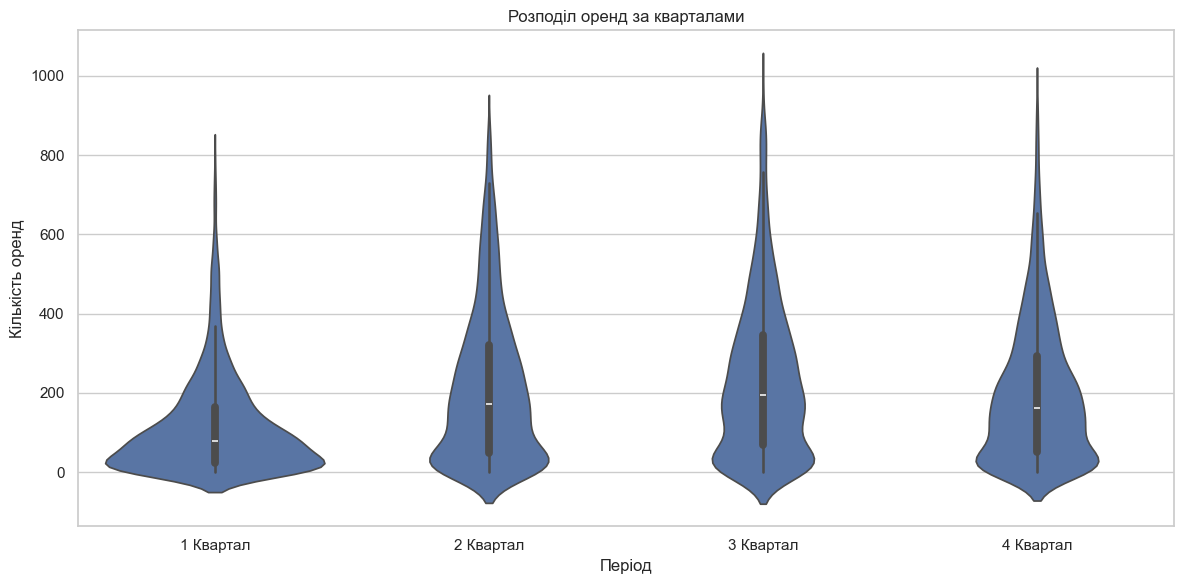

In [123]:
plt.figure(figsize=(12, 6))
ax1 = sns.violinplot(data=df, x='season', y='count')
plt.title('Розподіл оренд за кварталами')
plt.xticks([0,1,2,3],['1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал'])
plt.xlabel('Період')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

In [ ]:
"Товщина" violin plot показує щільність розподілу даних.
Найбільша варіабельність оренди у 3 кварталі, так як графік має більш витягнуту форму
Violin plot включає в себе інформацію з box plot, а також демонструє щільність розподілу даних та мультімодальність

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

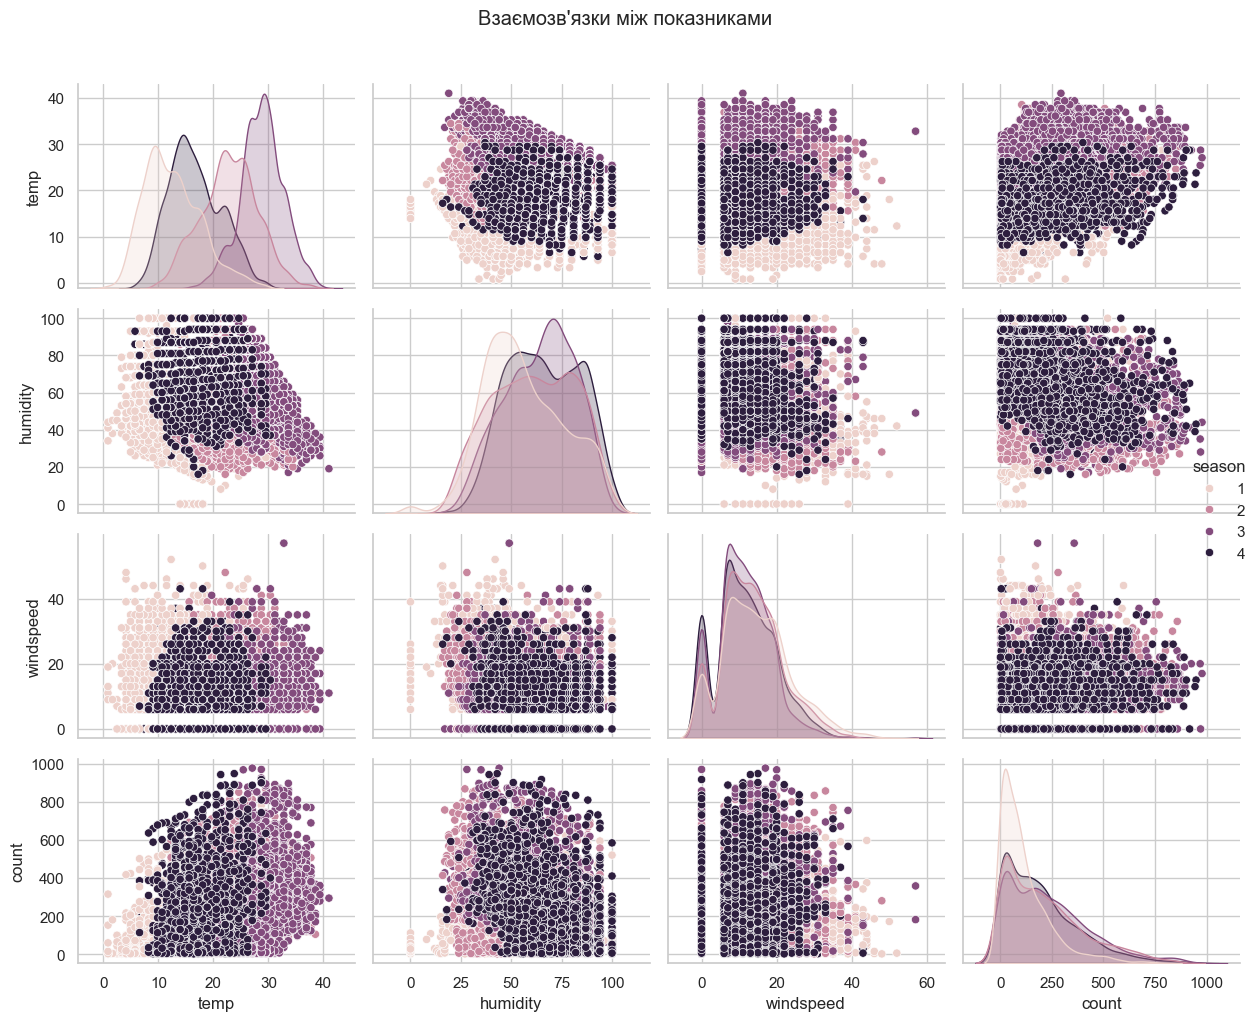

In [128]:
key_var_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(key_var_df, hue= 'season', height=2.5, aspect=1.2)
plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
Найсильніший лінійний зв'язок між 'temp' та 'count' - це видно з відповідного scatter plot
Між кварталами найбільше відрізняється 'temp' - це видно з відповідного діагонального графіку.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

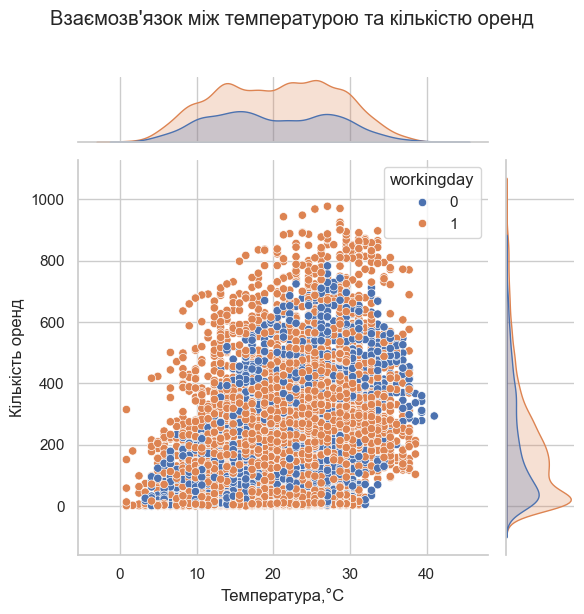

In [135]:
sns.jointplot(data=df, x='temp', y='count', hue='workingday')
plt.suptitle('Взаємозв\'язок між температурою та кількістю оренд', y=1.02)
plt.xlabel('Температура,°C')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

In [ ]:
По краях графіки показують розподіл кожної змінної
На scatter plot бачимо більшу кількість точок в робочі дні, тобто велосипеди орендують щоб дістатись до місця роботи
Сині точки - неробочі дні, орендують велосипеди для прогулянок і це відбувається при найбільш сприятливій температурі (15-32,°C)